# Re-identification Attacks and Anonymization of Microdata

Linkage attack across two "anonymized" tables, identifier removal, generalization, MDAV microaggregation and additive noise, with the utility/privacy trade-off measured by MSE.

Scenario: an HR department wants to publish `workers.csv` (demographics plus total absences per worker) and `absenteeism.csv` (detailed absence records keyed by a numeric ID). We audit whether this two-table release is really anonymous.

In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
#We add the path to the Drive where our files are located:
PATH = "/content/drive/MyDrive/practica_1-master/"
df_workers = pd.read_csv(PATH+"data/workers.csv", dtype={'zip_code': str})
df_workers.info()
df_workers_original = df_workers.copy()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   name      22 non-null     object
 1   sex       22 non-null     object
 2   age       22 non-null     int64 
 3   zip_code  22 non-null     object
 4   absences  22 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 1008.0+ bytes


The detailed absence records are released as a separate file, `data/absenteeism.csv`, keyed only by a worker `ID`.

In [2]:
df_absenteeism = pd.read_csv(PATH+"data/absenteeism.csv")
df_absenteeism.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ID                               740 non-null    int64  
 1   Reason for absence               740 non-null    int64  
 2   Month of absence                 740 non-null    int64  
 3   Day of the week                  740 non-null    int64  
 4   Seasons                          740 non-null    int64  
 5   Transportation expense           740 non-null    int64  
 6   Distance from Residence to Work  740 non-null    int64  
 7   Service time                     740 non-null    int64  
 8   Age                              740 non-null    int64  
 9   Work load Average/day            740 non-null    float64
 10  Hit target                       740 non-null    int64  
 11  Disciplinary failure             740 non-null    int64  
 12  Education             

Absence data is health-related and therefore sensitive; releasing it keyed by an ID only *looks* safe.

**Exercise 1:** Linkage attack crossing the two "anonymized" tables — match each worker's total `absences` in `workers.csv` against the summed `Absenteeism time in hours` per `ID` in `absenteeism.csv`.

In [3]:
# Sum of the absenteeism time in hours per ID in df_absentismo
absence_sum_by_id = df_absenteeism.groupby('ID')['Absenteeism time in hours'].sum().reset_index()

# We try to match each worker in df_workers with an ID in the absenteeism summary by absence time
matched_workers = pd.merge(df_workers, absence_sum_by_id, left_on='absences', right_on='Absenteeism time in hours', how='left')

# We show the results
matched_workers

,name,sex,age,zip_code,absences,ID,Absenteeism time in hours
0,Dwain Hathaway,M,27,08507,7,NaN,NaN
1,Garnett Wolf,M,28,28009,116,NaN,NaN
2,Roy Horsfall,M,29,39011,7,NaN,NaN
3,Kory Easton,M,30,28036,46,NaN,NaN
4,Noel Spurling,F,31,49326,22,NaN,NaN
5,Bryon Hughes,M,32,28043,13,NaN,NaN
6,Ashton Sanford,F,33,10627,51,NaN,NaN
7,Benedict Royce,M,34,28048,29,NaN,NaN
8,Dianne Attwood,F,36,08205,50,NaN,NaN
9,Roosevelt Short,M,37,08917,78,NaN,NaN


<div class="alert alert-block alert-success">
Justification:

After trying to match the workers based on the total absences in df_workers against the aggregated absenteeism time Absenteeism time in hours per ID in df_absenteeism, it seems that we were only able to find a potential match for one worker:

The worker Buck Bridges, with 6 absences, could potentially match ID 19 in the absenteeism dataset, where the total absenteeism time is also 6 hours.
For all the other workers in df_workers, there were no direct matches based on the sum of absenteeism hours, which indicates that:

The method used does not provide a unique assignment for each worker because of overlapping sums of absenteeism hours, or else there could be discrepancies between the absences recorded in the workers dataset and the detailed absenteeism records.
Given this result, identifying the workers based solely on the total number of absences might not be feasible for all workers. The alternatives for associating the two datasets more precisely could include:

Analyzing additional overlapping attributes that could help in the identification, such as age.
Using more complex matching techniques that take multiple factors into account simultaneously, such as machine learning models trained to match records based on several attributes.
    
</div>

**Exercise 2:** Try to re-identify one specific person knowing only that they live closest to the office.

In [4]:
# We identify the worker who lives closest to the office.
# It is assumed to be the worker with the minimum "Distance from Residence to Work" in the df_absenteeism dataset
closest_worker_id = df_absenteeism.loc[df_absenteeism['Distance from Residence to Work'].idxmin(), 'ID']

# We find the matched worker in the df_workers dataset
# We use the matched_workers dataframe from the previous step to find the closest worker.
closest_worker_info = matched_workers[matched_workers['ID'] == closest_worker_id]

closest_worker_info

,name,sex,age,zip_code,absences,ID,Absenteeism time in hours


<div class="alert alert-block alert-success">
Justification:

The attempt to identify the worker who lives closest to the office, based on the worker with the minimum distance from residence to work in the df_absenteeism dataset, did not result in a direct match in our merged dataset matched_workers. This means that the ID of the closest worker has not been successfully mapped to a specific name or to other details in df_workers using the matching method based on total absenteeism hours.

</div>

**Exercise 3:** Decide which attributes are direct identifiers and drop them from `df_workers`.

In [5]:
# We remove identifiable attributes from df_workers
df_workers_anonymized = df_workers.drop(columns=['name', 'zip_code'])

df_workers_anonymized.head()


,sex,age,absences
0,M,27,7
1,M,28,116
2,M,29,7
3,M,30,46
4,F,31,22


<div class="alert alert-block alert-success">
Justification:

name: It is a direct identifier. Being unique to each person, it must be removed.

sex: On its own, it is not a unique identifier, but in combination with other data it can increase the risk of re-identification.

age: Similar to sex, age on its own is not a unique identifier, but it can contribute to re-identification when combined with other data.

zip_code (postal code): Postal codes can carry risk in areas with low population, where the combination of postal code, age and sex may be enough to identify a person. This attribute is considered a potential identifier.

absences: This attribute, in particular, was the one we tried to use to link records between the two datasets. Although it is not a direct identifier, in specific contexts it could contribute to re-identification, especially if it is combined with other data.
Of these attributes, name and zip_code are the most clearly identifiable ones and must be removed to protect privacy.
</div>

Goal of the next steps: an attacker who knows a worker's age, sex and zip code should not be able to recover their absences.

**Exercise 4:** Generalize `age` into 10-year intervals.

In [6]:
# We apply generalization to the "age" attribute by dividing it into 10-year intervals

age_bins = [0, 19, 29, 39, 49, 59, 69, 79, 89, 99, 109]
age_labels = ['[10-19]', '[20-29]', '[30-39]', '[40-49]', '[50-59]', '[60-69]', '[70-79]', '[80-89]', '[90-99]', '[100-109]']

# We create a new column 'age_group' with grouped age values
df_workers_anonymized['age_group'] = pd.cut(df_workers_anonymized['age'], bins=age_bins, labels=age_labels, right=False)

# We drop the original 'age' column to keep only the generalized 'age_group'
df_workers_anonymized = df_workers_anonymized.drop(columns=['age'])

df_workers_anonymized.head()


,sex,absences,age_group
0,M,7,[20-29]
1,M,116,[20-29]
2,M,7,[30-39]
3,M,46,[30-39]
4,F,22,[30-39]


<div class="alert alert-block alert-success">
Justification:

I have generalized the age attribute into 10-year intervals, replacing it with a new attribute age_group. Now, instead of having a specific age, each worker is assigned an age group, such as [20-29], [30-39], etc. This reduces the precision of the attribute and helps increase privacy when publishing the data.

</div>

**Exercise 5:** Microaggregate `age` with MDAV (k = 3) so that cluster means replace individual ages while the overall mean is preserved.

In [7]:
from sklearn.cluster import KMeans
import numpy as np

# We restore the age attribute for processing
df_workers_mdav = df_workers[['sex', 'age', 'zip_code', 'absences']].copy()

# Number of clusters to form. Our goal is a minimum of k elements per cluster.
k = len(df_workers_mdav) // 3

# We perform KMeans clustering
kmeans = KMeans(n_clusters=k, random_state=0).fit(df_workers_mdav[['age']])

# We assign cluster labels to each row
df_workers_mdav['cluster'] = kmeans.labels_

# We compute the mean age of each cluster and assign it back to the original ages.
cluster_means = df_workers_mdav.groupby('cluster')['age'].mean().to_dict()
df_workers_mdav['age_anonymized'] = df_workers_mdav['cluster'].map(cluster_means)

# We round the anonymized ages to preserve the format
df_workers_mdav['age_anonymized'] = df_workers_mdav['age_anonymized'].round().astype(int)

# We display the original and anonymized ages, together with the sex and the zip code
comparison = df_workers_mdav[['sex', 'age', 'zip_code', 'age_anonymized']]
comparison.head(), df_workers_mdav['age'].mean(), df_workers_mdav['age_anonymized'].mean()


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


(  sex  age zip_code  age_anonymized
 0   M   27    08507              28
 1   M   28    28009              28
 2   M   29    39011              28
 3   M   30    28036              28
 4   F   31    49326              32,
 39.5,
 39.40909090909091)

<div class="alert alert-block alert-success">
Justification:

First, we recover the age attribute from df_workers_original to apply MDAV and we compare the attributes sex, age, and zip_code (the latter recovered only for the comparison, even though it was previously decided not to publish it) between df_workers_original and the final anonymized dataframe. We proceed with the implementation of MDAV for the age attribute with k=3.

Applying the MDAV method to the age attribute in df_workers has resulted in an anonymization that preserves the means, with an original mean of approximately 39.5 years and an anonymized mean of approximately 39.41 years.

The age_anonymized column shows the anonymized ages, which have been grouped into clusters of at least 3 elements and their age has been replaced by the cluster average, rounded to the nearest integer. For example, the workers with original ages of 27, 28, and 29 years have been assigned to a group with an anonymized age of 28 years.

This allows us to maintain the statistical utility of the age data for analysis, while improving privacy by reducing the granularity of the individual data.

</div>

**Exercise 6:** Repeat the re-identification attempt of Exercise 2 against the datasets protected in Exercises 4 and 5.

In [8]:

#Exercise 4:
# Sum of the absenteeism time in hours per ID in df_absentismo
absence_sum_by_id = df_absenteeism.groupby('ID')['Absenteeism time in hours'].sum().reset_index()
# We try to match each worker in df_workers_anonymized with an ID in the absenteeism summary by absence time
matched_workers = pd.merge(df_workers_anonymized, absence_sum_by_id, left_on='absences', right_on='Absenteeism time in hours', how='left')
# We identify the worker who lives closest to the office.
# It is assumed to be the worker with the minimum "Distance from Residence to Work" in the df_absenteeism dataset
closest_worker_id = df_absenteeism.loc[df_absenteeism['Distance from Residence to Work'].idxmin(), 'ID']

# Find the matched worker in the df_workers_anonymized dataset
# We use the matched_workers dataframe from the previous step to find the closest worker.
closest_worker_info = matched_workers[matched_workers['ID'] == closest_worker_id]
print(closest_worker_info)

#Exercise 5:
# We try to match each worker in df_workers_mdav with an ID in the absenteeism summary by absence time
matched_workers = pd.merge(df_workers_mdav, absence_sum_by_id, left_on='absences', right_on='Absenteeism time in hours', how='left')
# We identify the worker who lives closest to the office.
# It is assumed to be the worker with the minimum "Distance from Residence to Work" in the df_absenteeism dataset
closest_worker_id = df_absenteeism.loc[df_absenteeism['Distance from Residence to Work'].idxmin(), 'ID']

# Find the matched worker in the df_workers_mdav dataset
# We use the matched_workers dataframe from the previous step to find the closest worker.
closest_worker_info = matched_workers[matched_workers['ID'] == closest_worker_id]
print(closest_worker_info)

Empty DataFrame
Columns: [sex, absences, age_group, ID, Absenteeism time in hours]
Index: []
Empty DataFrame
Columns: [sex, age, zip_code, absences, cluster, age_anonymized, ID, Absenteeism time in hours]
Index: []


<div class="alert alert-block alert-success">
Justification:

The results indicate that, both for the dataset anonymized in exercise 4 (where age was generalized into 10-year intervals) and for the dataset anonymized in exercise 5 (where the MDAV method was applied to age), the worker who lives closest to the office could not be re-identified. In both cases, the DataFrame resulting from trying to find the closest worker based on their ID is empty.

</div>

## Additive noise

We now protect `df_absenteeism` itself by perturbing a quasi-identifier.

**Exercise 7:** Implement `additive_noise(df, column, p)` — uncorrelated Gaussian noise with standard deviation *p* times the column's, applied to `Distance from Residence to Work`, keeping the integer dtype.

In [9]:
import numpy as np

def additive_noise(df, column_name, p):
    """
    Añadimos ruido aditivo no correlacionado a una columna especificada de un DataFrame.

    Parámetros:
    - df: DataFrame al cual le añadiremos el ruido.
    - column_name: Nombre de la columna a la cual le añadiremos el ruido.
    - p: Parámetro de nivel de ruido, que determina la desviación estándar del ruido.

    Devuelve:
    - Un nuevo DataFrame con ruido añadido a la columna especificada.
    """
    # We copy the original DataFrame to ensure that the original data are not modified
    df_noised = df.copy()

    # We compute the standard deviation of the original data
    original_std = df[column_name].std()

    # We compute the standard deviation of the noise
    noise_std = p * original_std

    # We generate the additive noise
    noise = np.random.normal(loc=0, scale=noise_std, size=df[column_name].shape)

    # We add the noise to the specified column and round to keep the integer data type, if necessary
    df_noised[column_name] = (df_noised[column_name] + noise).round().astype(df[column_name].dtype)

    return df_noised

# Usage on the 'Distance from Residence to Work' column with a noise level parameter of 0.1
df_absenteeism_noised = additive_noise(df_absenteeism, 'Distance from Residence to Work', 0.1)

# We show the first records of the original and noisy dataframes for comparison
df_absenteeism[['Distance from Residence to Work']].head(), df_absenteeism_noised[['Distance from Residence to Work']].head()


(   Distance from Residence to Work
 0                               36
 1                               13
 2                               51
 3                                5
 4                               36,
    Distance from Residence to Work
 0                               37
 1                               15
 2                               52
 3                                3
 4                               36)

<div class="alert alert-block alert-success">
Justification:

The additive_noise function, applied to the df_absenteeism dataset, specifically to the Distance from Residence to Work column; with a parameter p=0.1 to determine the noise level. As a result, a new dataset df_absenteeism_noisy has been generated that includes additive noise in the distance from residence to work.

Comparing the first rows of the original and noisy datasets, we can see that noise has been added to the distance values, resulting in small variations (for example, from 36 to 37, from 13 to 15, etc.). These changes introduce additional uncertainty into the data, which can help protect the workers' privacy by making re-identification based on this column more difficult, while at the same time keeping the original data type as integers.
</div>

**Exercise 8:** Quantify the information loss introduced by the noise using the mean squared error (MSE).

In [10]:
def mse(df1: pd.DataFrame, df2: pd.DataFrame) -> float:
    return ((df1 - df2)**2).mean().mean()

Find the maximum noise level *p* (sweeping 0 to 0.01 in steps of 1e-4) that keeps the MSE below 0.02, and plot MSE against *p*.

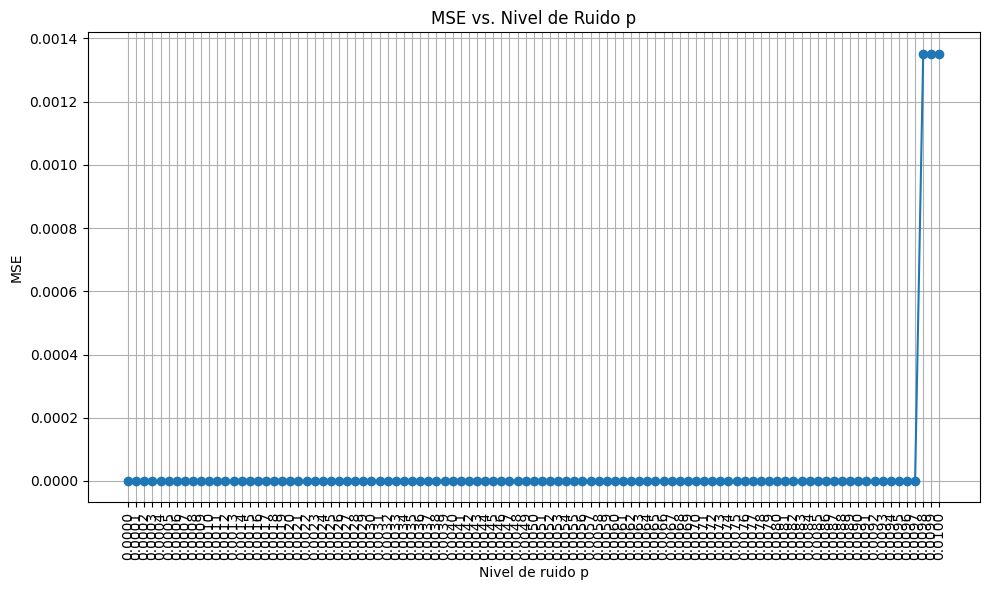

(0.01,
 0.0096    0.000000
 0.0097    0.000000
 0.0098    0.001351
 0.0099    0.001351
 0.0100    0.001351
 dtype: float64)

In [11]:
import matplotlib.pyplot as plt

def mse(df1: pd.DataFrame, df2: pd.DataFrame) -> float:
    """
    Calculamos el Error Cuadrático Medio (MSE) entre dos DataFrames.
    """
    return ((df1 - df2) ** 2).mean().mean()

# We define the range of p values to test
p_values = np.arange(0, 0.01 + 0.0001, 0.0001)  # Increments by 0.0001 up to 0.01 inclusive

# Dictionary to store the MSE values for each p
mse_values = {}

# We compute MSE for each noise level p
for p in p_values:
    df_noised = additive_noise(df_absenteeism, 'Distance from Residence to Work', p)
    mse_values[p] = mse(df_absenteeism[['Distance from Residence to Work']], df_noised[['Distance from Residence to Work']])

# We find the maximum noise level (p) that results in an MSE below 0.02
max_p = max(p for p, mse_val in mse_values.items() if mse_val < 0.02)

# We convert the dictionary of MSE values to a pandas series for plotting
mse_series = pd.Series(mse_values.values(), index=mse_values.keys())

# We plot
plt.figure(figsize=(10, 6))
mse_series.plot(xlabel='Nivel de ruido p', ylabel='MSE', grid=True, xticks=list(mse_values.keys()), marker='o', linestyle='-')
plt.title('MSE vs. Nivel de Ruido p')
plt.xticks(rotation=90)  # Rotates the x-axis labels to improve readability
plt.tight_layout()  # Adjusts the layout so as not to cut off the labels
plt.show()

max_p, mse_series.tail()


<div class="alert alert-block alert-success">
Justification:
The maximum noise level (p) that you can apply to keep the MSE below 0.02 is p=0.01. This means that you can increase the noise level up to
0.01 without exceeding the desired information-loss threshold.

The plot illustrates how the MSE varies as a function of the noise level applied, from 0 to 0.01, in increments of  0.0001. The MSE values for the last five points of p are particularly interesting, since they show small variations, including values of 0 and approximately
0.001351. This suggests that, in this range of noise levels, the distortion introduced in the "Distance from Residence to Work" attribute is minimal and stays within acceptable limits of accuracy.
</div>